In [ ]:
import py_dss_interface
from py_dss_toolkit import dss_tools
import pandas as pd

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"
#dss_file = r"C:\Users\IVAN SANTOS\Documents\OpenDSS\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}


dfs_monitor = {}
df_energymeter = pd.DataFrame(columns=["Caso", "Perdas (kWh)", "Energia (kWh)", "Energia injetada (kWh)"])
dfs_voltage = {}
dfs_monitor_pv = {}

for case in cases:

    dss.text(f"compile [{dss_file}]")

    if case == "60_gd":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        dss.text("Redirect 'Monitor_PV.dss'")
    
    elif case == "120_gd":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
    
    elif case == "60_gd_30_bess":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        dss.text("Redirect 'BATERIAS_30.dss'")

    elif case == "120_gd_60_bess":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        dss.text("Redirect 'BATERIAS_60.dss'")

    else:
        dss.text("!Redirect 'BATERIAS_60.dss'")
    
    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=1")

    for h in range(48):
        if dss.solution.hour == 24:
            dss.meters.reset_all()
        dss.solution.solve()

    #dss.text("sample")

    meter_values = dss.meters.register_values

    print(f"\n {titles[case]}\n")
    print(f"Energia total: {meter_values[0]:.2f} kWh")
    print(f"Perdas totais: {meter_values[12]:.2f} kWh\n")

    ##### Monitor - Power Flow Substation ####

    dfs_monitor[f"{case}_df"] = dss_tools.results.monitor("feeder")
    dfs_monitor[f"{case}_df"]["Total Power"] = dfs_monitor[f"{case}_df"][' P1 (kW)'] + dfs_monitor[f"{case}_df"][' P2 (kW)'] + dfs_monitor[f"{case}_df"][' P3 (kW)']

    ##### Monitors - Voltage #####

    monitor_names = dss.monitors.names

    for monitor_name in monitor_names:
        if "voltage" in monitor_name.lower():
            dfs_voltage[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)
        
        ##### Monitors - Power Flow PV #####

        else:
            dfs_monitor_pv[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)

    
    injection = 0
    for chave, df in dfs_monitor_pv.items():

        if chave.endswith(f"_{case}_df") and "trf_" in chave:
            if " P3 (kW)" in df.columns:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"] + df[" P3 (kW)"]
            else:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"]

            injection += df.query("`Total Power` < 0 and Hour > 23")["Total Power"].sum()

    ######## Criação do DataFrame "Energymeter" #####
    nova_linha = pd.DataFrame([{
        "Caso": titles[case], 
        "Energia (kWh)": meter_values[0], 
        "Perdas (kWh)": meter_values[12],
        "Energia injetada (kWh)": injection
    }])

    df_energymeter = pd.concat([df_energymeter, nova_linha], ignore_index=True)

#display(dfs_monitor["120_gd_60_bess_df"])
display(df_energymeter)
print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)



 Caso Base

Energia total: 124421.28 kWh
Perdas totais: 6277.88 kWh


 Caso com 60 GDs

Energia total: 78896.61 kWh
Perdas totais: 5348.56 kWh


 Caso com 60 GDs e 30 Baterias

Energia total: 79094.52 kWh
Perdas totais: 4109.81 kWh


 Caso com 120 GDs

Energia total: 49444.51 kWh
Perdas totais: 5882.47 kWh


 Caso com 120 GDs e 60 Baterias

Energia total: 49006.92 kWh
Perdas totais: 3309.96 kWh



,Caso,Perdas (kWh),Energia (kWh),Energia injetada (kWh)
0,Caso Base,6277.879191,124421.278044,0.0
1,Caso com 60 GDs,5348.555803,78896.6063,-26567.828373
2,Caso com 60 GDs e 30 Baterias,4109.805898,79094.522527,-11735.364041
3,Caso com 120 GDs,5882.469108,49444.513986,-43688.849394
4,Caso com 120 GDs e 60 Baterias,3309.960776,49006.920301,-17970.380908


Index(['Hour', 'sec', ' V1', ' VAngle1', ' V2', ' VAngle2', ' V3', ' VAngle3',
       ' V4', ' VAngle4', ' I1', ' IAngle1', ' I2', ' IAngle2', ' I3',
       ' IAngle3', ' I4', ' IAngle4'],
      dtype='str')


Dados de Potência

,Caso,Perdas,Energia
0,base_df,6277.879191,124421.278044
1,60_gd_df,5348.555803,78896.6063
2,60_gd_30_bess_df,4109.805898,79094.522527
3,120_gd_df,5882.469108,49444.513986
4,120_gd_60_bess_df,3309.960776,49006.920301


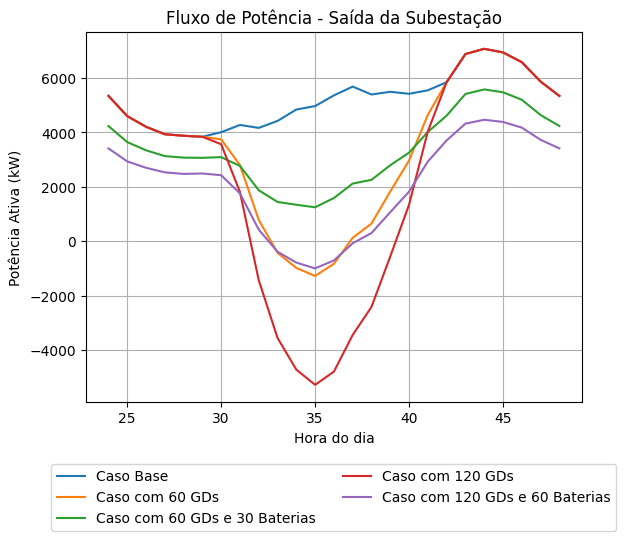

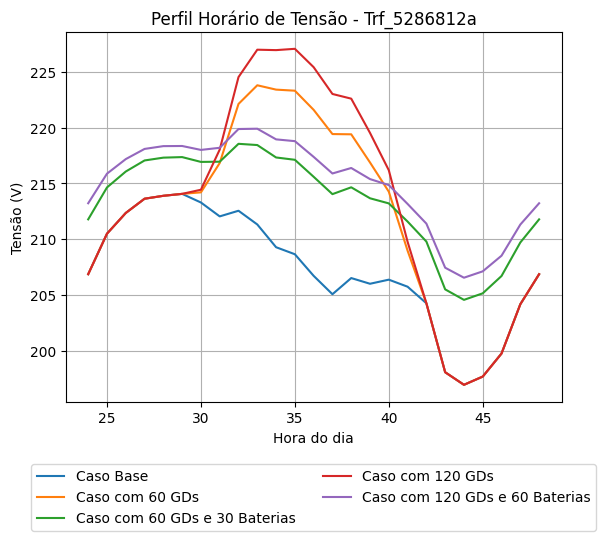

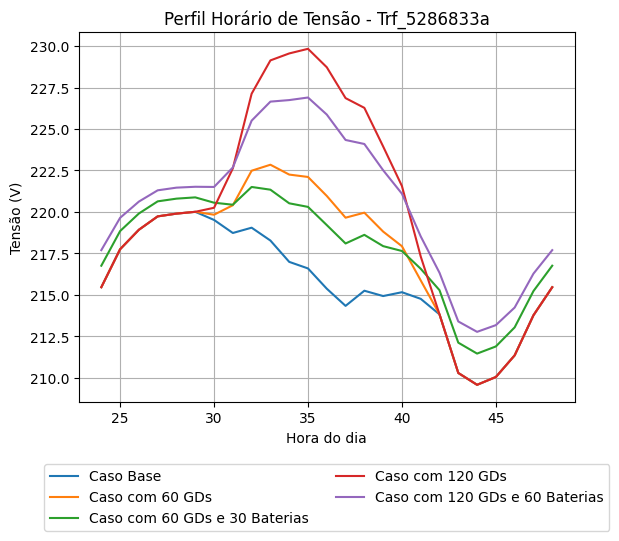

In [2]:
#Resultados

import matplotlib.pyplot as plt

display(df_energymeter)

titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}
#Gráfico Subestação Fluxo de Potência
for case in cases:
    dfs_monitor[f"{case}_df"] = dfs_monitor[f"{case}_df"].query("Hour > 23")
    plt.plot(
        dfs_monitor[f"{case}_df"]["Hour"], 
        dfs_monitor[f"{case}_df"]["Total Power"], label=titles[case])
    

plt.title("Fluxo de Potência - Saída da Subestação")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

#Gráfico Tensão Trf 5286812a
for case in cases:
    df1 = dfs_voltage[f"voltage_trf_5286812a_{case}_df"].query("Hour > 23")
    plt.plot(
        df1["Hour"], 
        df1[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286812a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

#Gráfico Tensão Trf_5286833a
for case in cases:
    df2= dfs_voltage[f"voltage_trf_5286833a_{case}_df"].query("Hour > 23")
    plt.plot(
        df2["Hour"], 
        df2[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286833a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.style.use("dark_background")
plt.show()



Mapas

In [16]:
#Rodar apenas quando for criar os mapas
dss.text("set mode=daily")
dss.text("set stepsize=1h")
dss.text("set number=1")

for _ in range(36):   # chega até a hora 35 (hora com maiores valores de tensão)
    dss.solution.solve()

#Rodar o código principal novamente para ter todos os dados

Version 11.0.0.1 (64-bit build) - Charlottesville; License Status: Open 


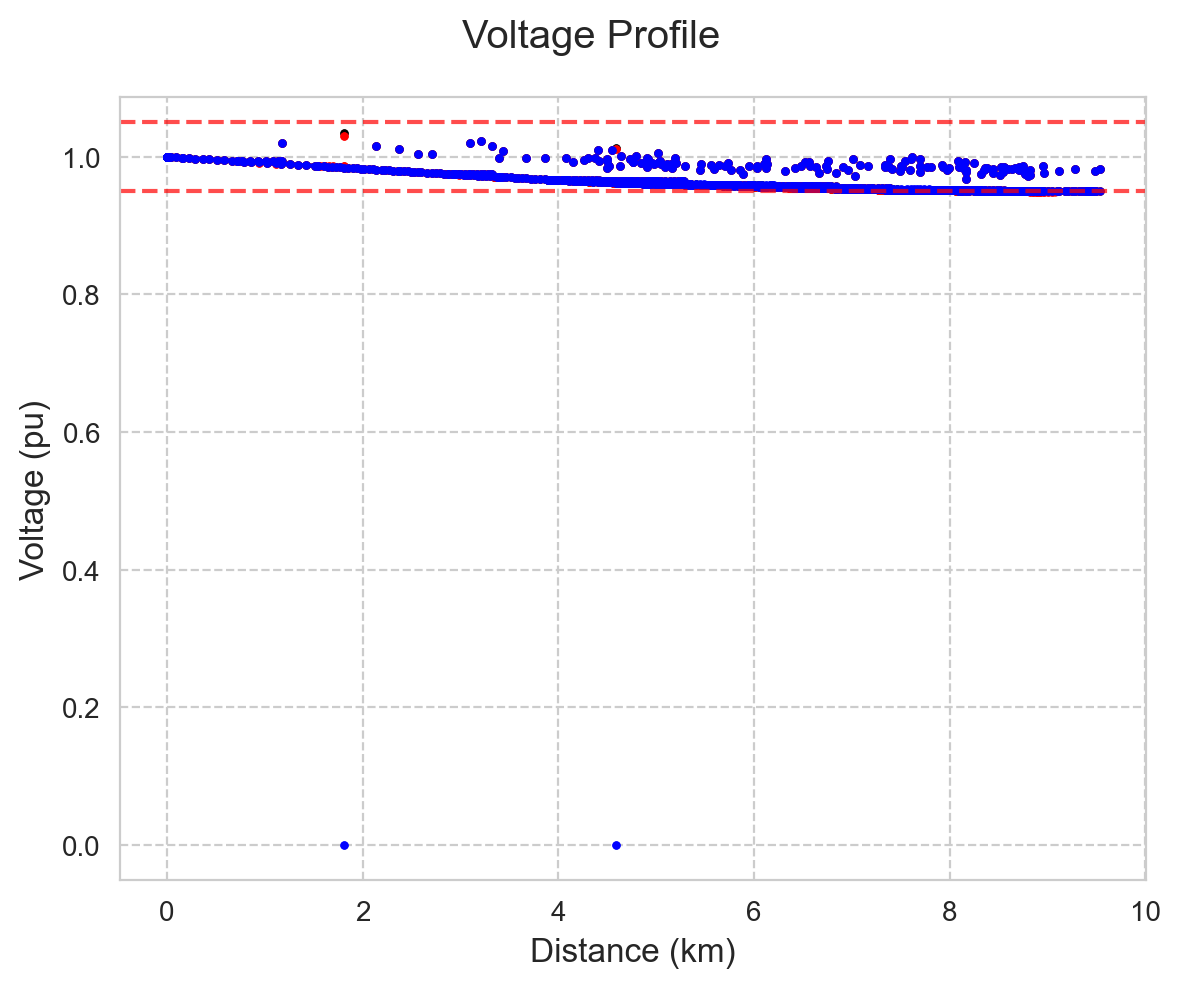

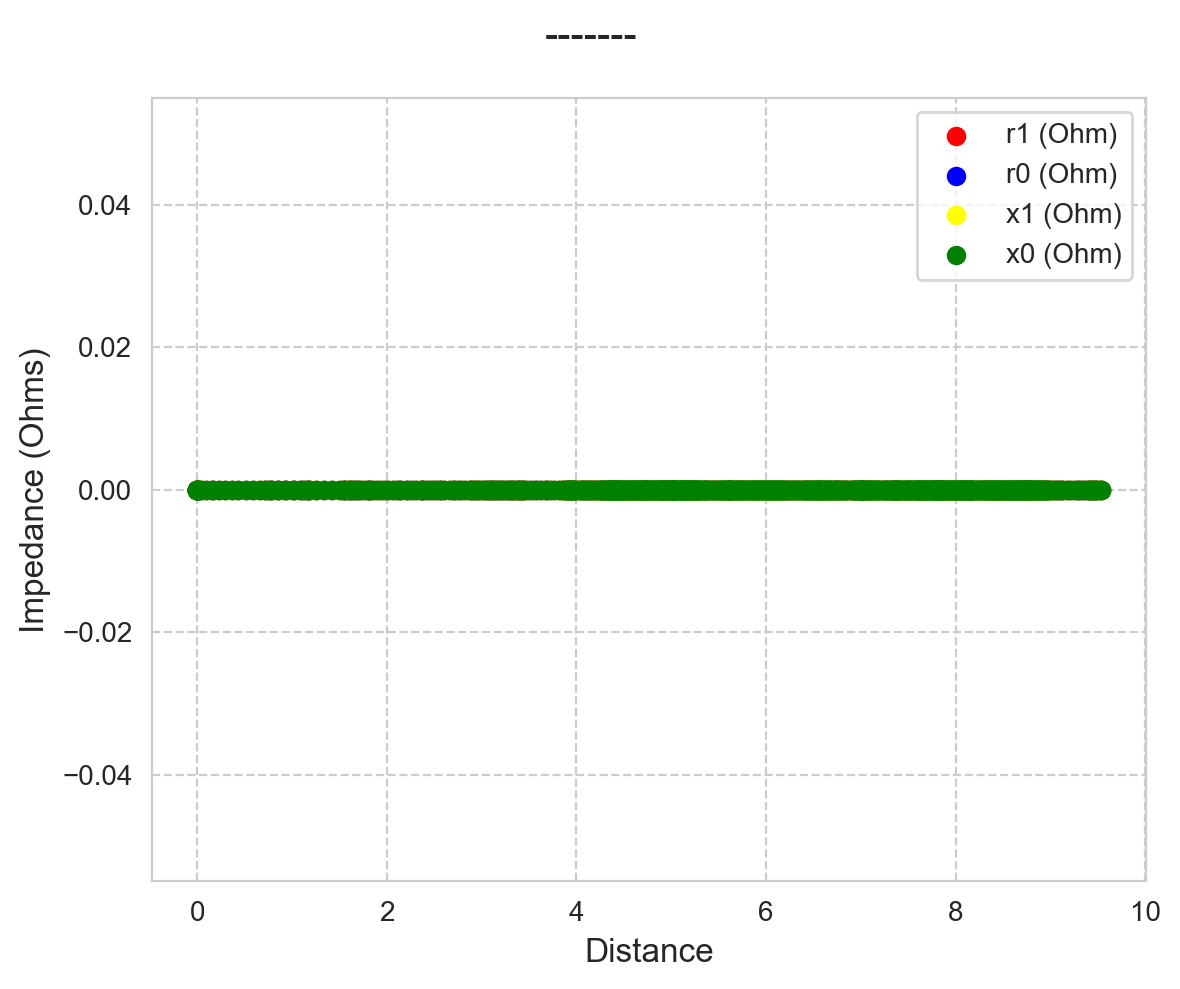

In [ ]:
#Rodar 

print(dss.dssinterface.version)
dss_tools.update_dss(dss)
########## Mapas ############

dss_tools.interactive_view.circuit_plot(parameter="voltage", show=True)
dss_tools.interactive_view.circuit_geoplot(parameter="voltage", show=True)
#dss_tools.interactive_view.voltage_profile(show=True)
dss_tools.static_view.voltage_profile(show=True, legend=False)
dss_tools.static_view.impedances_vs_distance(show=True)


Análise das Tensões

In [25]:
monitor_names = dss.monitors.names
cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
voltages = ["V1", "V2", "V3"]

for monitor in monitor_names:
    if "voltage" not in monitor.lower():
        continue
    
    base = dfs_voltage[f"{monitor}_base_df"]

    for case in cases:
        df = dfs_voltage[f"{monitor}_{case}_df"]

        for v in voltages:

            if case == "base":
                df[f"diff_percent_{v}"] = 0.0
                continue
            
            if f" {v}" not in df.columns:
                continue

            df[f"diff_percent_{v}"] = 100*(df[f" {v}"] - base[f" {v}"])/base[f" {v}"]

estatisticas = []

for nome, df in dfs_voltage.items():

    linha = {"Monitor": nome}
    
    df = df.query("Hour > 23")

    if df.empty:
        continue

    for v in voltages:

        if f" {v}" not in df.columns:
            continue

        linha[f"{v}_max"] = df[f" {v}"].max()
        linha[f"{v}_hora_max"] = df.loc[df[f" {v}"].idxmax(), "Hour"]
        linha[f"{v}_min"] = df[f" {v}"].min()
        linha[f"{v}_hora_min"] = df.loc[df[f" {v}"].idxmin(), "Hour"]
        linha[f"{v}_medio"] = df[f" {v}"].mean()

        if f"diff_percent_{v}" in df.columns:
            linha[f"diff_{v}_max"] = df[f"diff_percent_{v}"].max()
            linha[f"diff_{v}_hora_max"] = df.loc[df[f"diff_percent_{v}"].idxmax(), "Hour"]
            linha[f"diff_{v}_min"] = df[f"diff_percent_{v}"].min()
            linha[f"diff_{v}_hora_min"] = df.loc[df[f"diff_percent_{v}"].idxmin(), "Hour"]

    estatisticas.append(linha)

df_stats = pd.DataFrame(estatisticas)

print("\n Maiores elevações percentuais V1\n")
df_stats = df_stats.sort_values(by='diff_V1_max', ascending=False)
display(df_stats.head(5))

print("\n Maiores valores de tensão V1\n")
df_stats_bt = df_stats.query("V1_max < 1000")
display(df_stats_bt.sort_values(by='V1_max', ascending=False).head(5))

print("\n Maiores elevações percentuais V2\n")
df_stats = df_stats.sort_values(by='diff_V2_max', ascending=False)
display(df_stats[["diff_V2_max", "diff_V2_hora_max"]].head(5))

print("\n Maiores valores de tensão V2\n")
display(df_stats_bt[["V2_max", "V2_hora_max"]].sort_values(by='V2_max', ascending=False).head(5))

print("\n Maiores elevações percentuais V3\n")
df_stats = df_stats.sort_values(by='diff_V3_max', ascending=False)
display(df_stats.head(5))

print("\n Maiores valores de tensão V3\n")
display(df_stats_bt.sort_values(by='V3_max', ascending=False).head(5))


#display(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"])
#print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)


 Maiores elevações percentuais V1



,Monitor,V1_max,V1_hora_max,V1_min,V1_hora_min,V1_medio,diff_V1_max,diff_V1_hora_max,diff_V1_min,diff_V1_hora_min,...,diff_V2_hora_min,V3_max,V3_hora_max,V3_min,V3_hora_min,V3_medio,diff_V3_max,diff_V3_hora_max,diff_V3_min,diff_V3_hora_min
462,voltage_trf_5286812a_120_gd_df,227.060974,35.0,196.943939,44.0,213.337908,9.047834,36.0,0.0,24.0,...,24.0,227.057983,35.0,196.940018,44.0,213.334893,9.047926,36.0,0.0,24.0
460,voltage_trf_5286810a_120_gd_df,228.155777,35.0,200.046127,44.0,215.087588,8.478471,36.0,0.0,24.0,...,24.0,228.152786,35.0,200.042130,44.0,215.084542,8.478569,36.0,0.0,24.0
465,voltage_trf_5286815a_120_gd_df,228.450653,35.0,200.598709,44.0,215.431116,8.436846,36.0,0.0,24.0,...,24.0,228.447662,35.0,200.594696,44.0,215.428069,8.436928,36.0,0.0,24.0
471,voltage_trf_5286821a_120_gd_df,227.594528,35.0,199.689880,44.0,214.790303,8.325383,36.0,0.0,24.0,...,24.0,227.591553,35.0,199.685898,44.0,214.787266,8.325464,36.0,0.0,24.0
514,voltage_trf_5286933a_120_gd_df,227.875381,35.0,200.093903,44.0,215.036077,8.323770,36.0,0.0,24.0,...,24.0,227.872391,35.0,200.089905,44.0,215.033040,8.323858,36.0,0.0,24.0



 Maiores valores de tensão V1



,Monitor,V1_max,V1_hora_max,V1_min,V1_hora_min,V1_medio,diff_V1_max,diff_V1_hora_max,diff_V1_min,diff_V1_hora_min,...,diff_V2_hora_min,V3_max,V3_hora_max,V3_min,V3_hora_min,V3_medio,diff_V3_max,diff_V3_hora_max,diff_V3_min,diff_V3_hora_min
477,voltage_trf_5286833a_120_gd_df,229.836899,35.0,209.575394,44.0,219.973140,6.200285,36.0,0.0,24.0,...,24.0,229.834045,35.0,209.571411,44.0,219.970193,6.200351,36.0,0.0,24.0
435,voltage_trf_5286708a_120_gd_df,229.822052,33.0,224.385132,44.0,227.414504,1.404136,36.0,0.0,24.0,...,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433,voltage_trf_5286699a_120_gd_df,229.598328,35.0,215.508148,44.0,223.038577,4.076147,36.0,0.0,24.0,...,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
492,voltage_trf_5286858a_120_gd_df,229.478409,35.0,206.204712,44.0,218.244100,7.157523,36.0,0.0,24.0,...,24.0,229.475586,35.0,206.200760,44.0,218.241177,7.157610,36.0,0.0,24.0
495,voltage_trf_5286862a_120_gd_df,229.451050,35.0,204.938934,44.0,217.627348,7.577894,36.0,0.0,24.0,...,24.0,229.448227,35.0,204.934982,44.0,217.624434,7.577994,36.0,0.0,24.0



 Maiores elevações percentuais V2



...

,V2_max,V2_hora_max
477,229.835922,35.0
492,229.477432,35.0
495,229.450089,35.0
499,229.440323,35.0
479,229.436478,35.0



 Maiores elevações percentuais V3



,Monitor,V1_max,V1_hora_max,V1_min,V1_hora_min,V1_medio,diff_V1_max,diff_V1_hora_max,diff_V1_min,diff_V1_hora_min,...,diff_V2_hora_min,V3_max,V3_hora_max,V3_min,V3_hora_min,V3_medio,diff_V3_max,diff_V3_hora_max,diff_V3_min,diff_V3_hora_min
462,voltage_trf_5286812a_120_gd_df,227.060974,35.0,196.943939,44.0,213.337908,9.047834,36.0,0.0,24.0,...,24.0,227.057983,35.0,196.940018,44.0,213.334893,9.047926,36.0,0.0,24.0
460,voltage_trf_5286810a_120_gd_df,228.155777,35.0,200.046127,44.0,215.087588,8.478471,36.0,0.0,24.0,...,24.0,228.152786,35.0,200.042130,44.0,215.084542,8.478569,36.0,0.0,24.0
465,voltage_trf_5286815a_120_gd_df,228.450653,35.0,200.598709,44.0,215.431116,8.436846,36.0,0.0,24.0,...,24.0,228.447662,35.0,200.594696,44.0,215.428069,8.436928,36.0,0.0,24.0
471,voltage_trf_5286821a_120_gd_df,227.594528,35.0,199.689880,44.0,214.790303,8.325383,36.0,0.0,24.0,...,24.0,227.591553,35.0,199.685898,44.0,214.787266,8.325464,36.0,0.0,24.0
514,voltage_trf_5286933a_120_gd_df,227.875381,35.0,200.093903,44.0,215.036077,8.323770,36.0,0.0,24.0,...,24.0,227.872391,35.0,200.089905,44.0,215.033040,8.323858,36.0,0.0,24.0



 Maiores valores de tensão V3



,Monitor,V1_max,V1_hora_max,V1_min,V1_hora_min,V1_medio,diff_V1_max,diff_V1_hora_max,diff_V1_min,diff_V1_hora_min,...,diff_V2_hora_min,V3_max,V3_hora_max,V3_min,V3_hora_min,V3_medio,diff_V3_max,diff_V3_hora_max,diff_V3_min,diff_V3_hora_min
477,voltage_trf_5286833a_120_gd_df,229.836899,35.0,209.575394,44.0,219.973140,6.200285,36.0,0.0,24.0,...,24.0,229.834045,35.0,209.571411,44.0,219.970193,6.200351,36.0,0.0,24.0
492,voltage_trf_5286858a_120_gd_df,229.478409,35.0,206.204712,44.0,218.244100,7.157523,36.0,0.0,24.0,...,24.0,229.475586,35.0,206.200760,44.0,218.241177,7.157610,36.0,0.0,24.0
495,voltage_trf_5286862a_120_gd_df,229.451050,35.0,204.938934,44.0,217.627348,7.577894,36.0,0.0,24.0,...,24.0,229.448227,35.0,204.934982,44.0,217.624434,7.577994,36.0,0.0,24.0
499,voltage_trf_5286866a_120_gd_df,229.441299,35.0,204.840836,44.0,217.576998,7.606914,36.0,0.0,24.0,...,24.0,229.438477,35.0,204.836899,44.0,217.574085,7.607000,36.0,0.0,24.0
479,voltage_trf_5286835a_120_gd_df,229.437454,35.0,208.721008,44.0,219.468762,6.289025,36.0,0.0,24.0,...,24.0,229.434616,35.0,208.717041,44.0,219.465825,6.289099,36.0,0.0,24.0


In [30]:
#Linhas

line_df = dss_tools.model.lines_df
line_df['name'] = 'line.' + line_df['name']
num_phases = line_df.set_index("name")["phases"]
dss_tools.interactive_view.user_categorical_defined_settings.results = num_phases
dss_tools.interactive_view.user_categorical_defined_settings.color_map = {'3': ["3-phases", "blue"],
        '2': ["2-phases", "red"],
        '1': ["1-phase", "green"]}
dss_tools.interactive_view.circuit_plot(parameter="user categorical defined", title="My Phases")

#Gráfico interativo transformadores

dss_tools.interactive_view.vmag_vs_time("voltage_trf_5286833a", show=True)
dss_tools.interactive_view.p_vs_time("feeder", show=True)



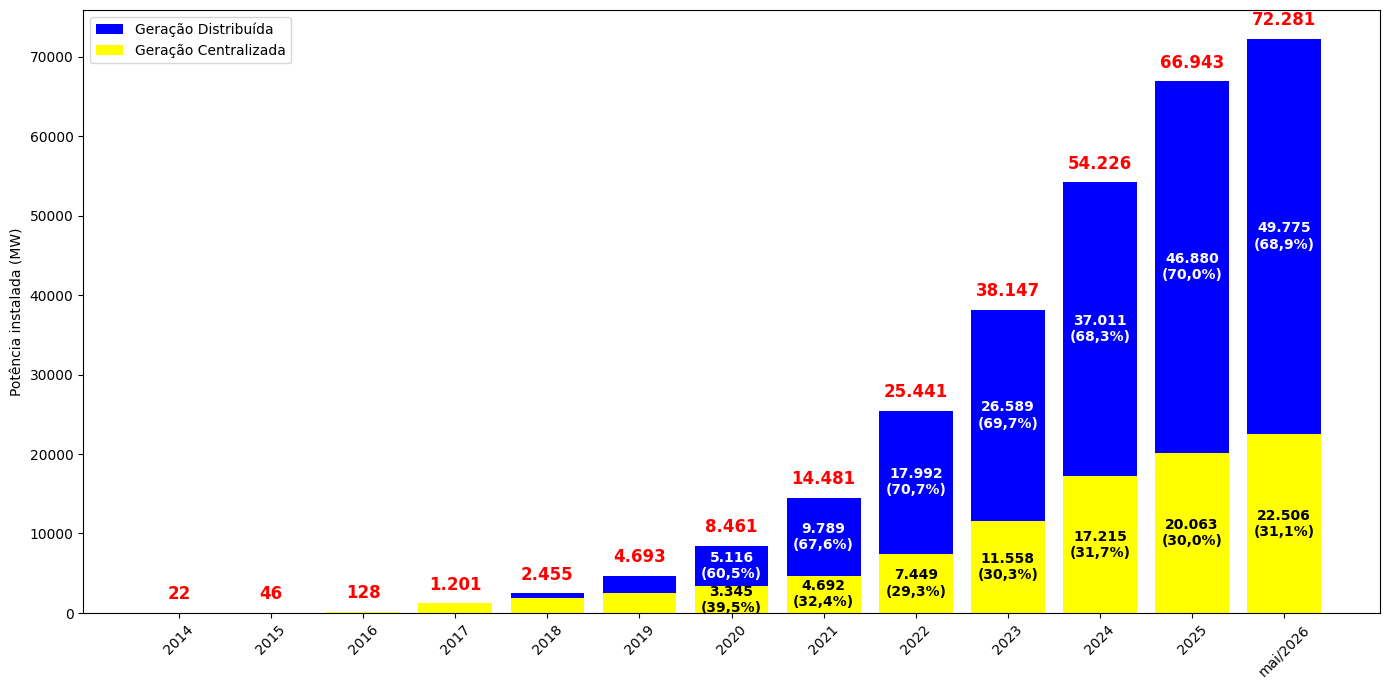

In [15]:
import matplotlib.pyplot as plt
import numpy as np

categorias = [
    "2014", "2015", "2016", "2017", "2018", "2019",
    "2020", "2021", "2022", "2023", "2024", "2025", "mai/2026"
]

serie_1 = [
    0, 0, 0, 0, 601, 2181,
    5116, 9789, 17992, 26589, 37011, 46880, 49775
]

serie_2 = [
    22, 46, 128, 1201, 1854, 2512,
    3345, 4692, 7449, 11558, 17215, 20063, 22506
]

plt.figure(figsize=(14, 7))

barras_1 = plt.bar(
    categorias,
    serie_1,
    label="Geração Distribuída",
    color="blue",
    bottom=serie_2
)

barras_2 = plt.bar(
    categorias,
    serie_2,
    label="Geração Centralizada",
    color="yellow"
)

totais = np.array(serie_1) + np.array(serie_2)

for barra_1, barra_2, valor_1, valor_2, total in zip(
        barras_1, barras_2, serie_1, serie_2, totais):

    x = barra_1.get_x() + barra_1.get_width() / 2

    # Geração centralizada (agora embaixo)
    if valor_2 >= 3000:

        porcentagem_2 = 100 * valor_2 / total

        texto_2 = (
            f"{valor_2:,}\n"
            f"({porcentagem_2:.1f}%)"
        )

        texto_2 = texto_2.replace(",", "X")
        texto_2 = texto_2.replace(".", ",")
        texto_2 = texto_2.replace("X", ".")

        plt.text(
            x,
            valor_2 / 2,
            texto_2,
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            fontweight="bold"
        )

    # Geração distribuída (agora em cima)
    if valor_1 >= 3000:

        porcentagem_1 = 100 * valor_1 / total

        texto_1 = (
            f"{valor_1:,}\n"
            f"({porcentagem_1:.1f}%)"
        )

        texto_1 = texto_1.replace(",", "X")
        texto_1 = texto_1.replace(".", ",")
        texto_1 = texto_1.replace("X", ".")

        plt.text(
            x,
            valor_2 + valor_1 / 2,
            texto_1,
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            fontweight="bold"
        )

    # Valor total (sempre aparece)
    texto_total = f"{total:,}".replace(",", ".")

    plt.text(
        x,
        total + 1200,
        texto_total,
        ha="center",
        va="bottom",
        fontsize=12,
        color="red",
        fontweight="bold"
    )

plt.ylabel("Potência instalada (MW)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [20]:
dss_tools.interactive_view.circuit_geoplot(parameter="phases", show=True, title="Alimentador 5 da Subestação Meia Ponte")
#dss_tools.interactive_view.user_numerical_defined_settings.

df_energymeter.to_csv("Dados energia CBA.csv")

